In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [ ]:
data_path = "/content/drive/MyDrive/Network Intrusion Detection Dataset/KDDTrain+.txt"
df = pd.read_csv(data_path, header=None)
print("Bentuk dataset:", df.shape)
print("\n5 baris pertama:")
print(df.head())

Bentuk dataset: (125973, 43)

5 baris pertama:
   0    1         2   3    4     5   6   7   8   9   ...    33    34    35  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...  0.17  0.03  0.17   
1   0  udp     other  SF  146     0   0   0   0   0  ...  0.00  0.60  0.88   
2   0  tcp   private  S0    0     0   0   0   0   0  ...  0.10  0.05  0.00   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  1.00  0.00  0.03   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  1.00  0.00  0.00   

     36    37    38    39    40       41  42  
0  0.00  0.00  0.00  0.05  0.00   normal  20  
1  0.00  0.00  0.00  0.00  0.00   normal  15  
2  0.00  1.00  1.00  0.00  0.00  neptune  19  
3  0.04  0.03  0.01  0.00  0.01   normal  21  
4  0.00  0.00  0.00  0.00  0.00   normal  21  

[5 rows x 43 columns]


**1. EKSPLORASI DAN PERSIAPAN DATA**

In [ ]:
# Tambahkan nama kolom agar lebih mudah dibaca
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment",
    "urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted",
    "num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]
col_names.append("difficulty_level")
df.columns = col_names

In [ ]:
# Pisahkan kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

print("\nKolom numerik:", list(num_cols))
print("\nKolom kategorikal:", list(cat_cols))


Kolom numerik: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty_level']

Kolom kategorikal: ['protocol_type', 'service', 'flag', 'label']


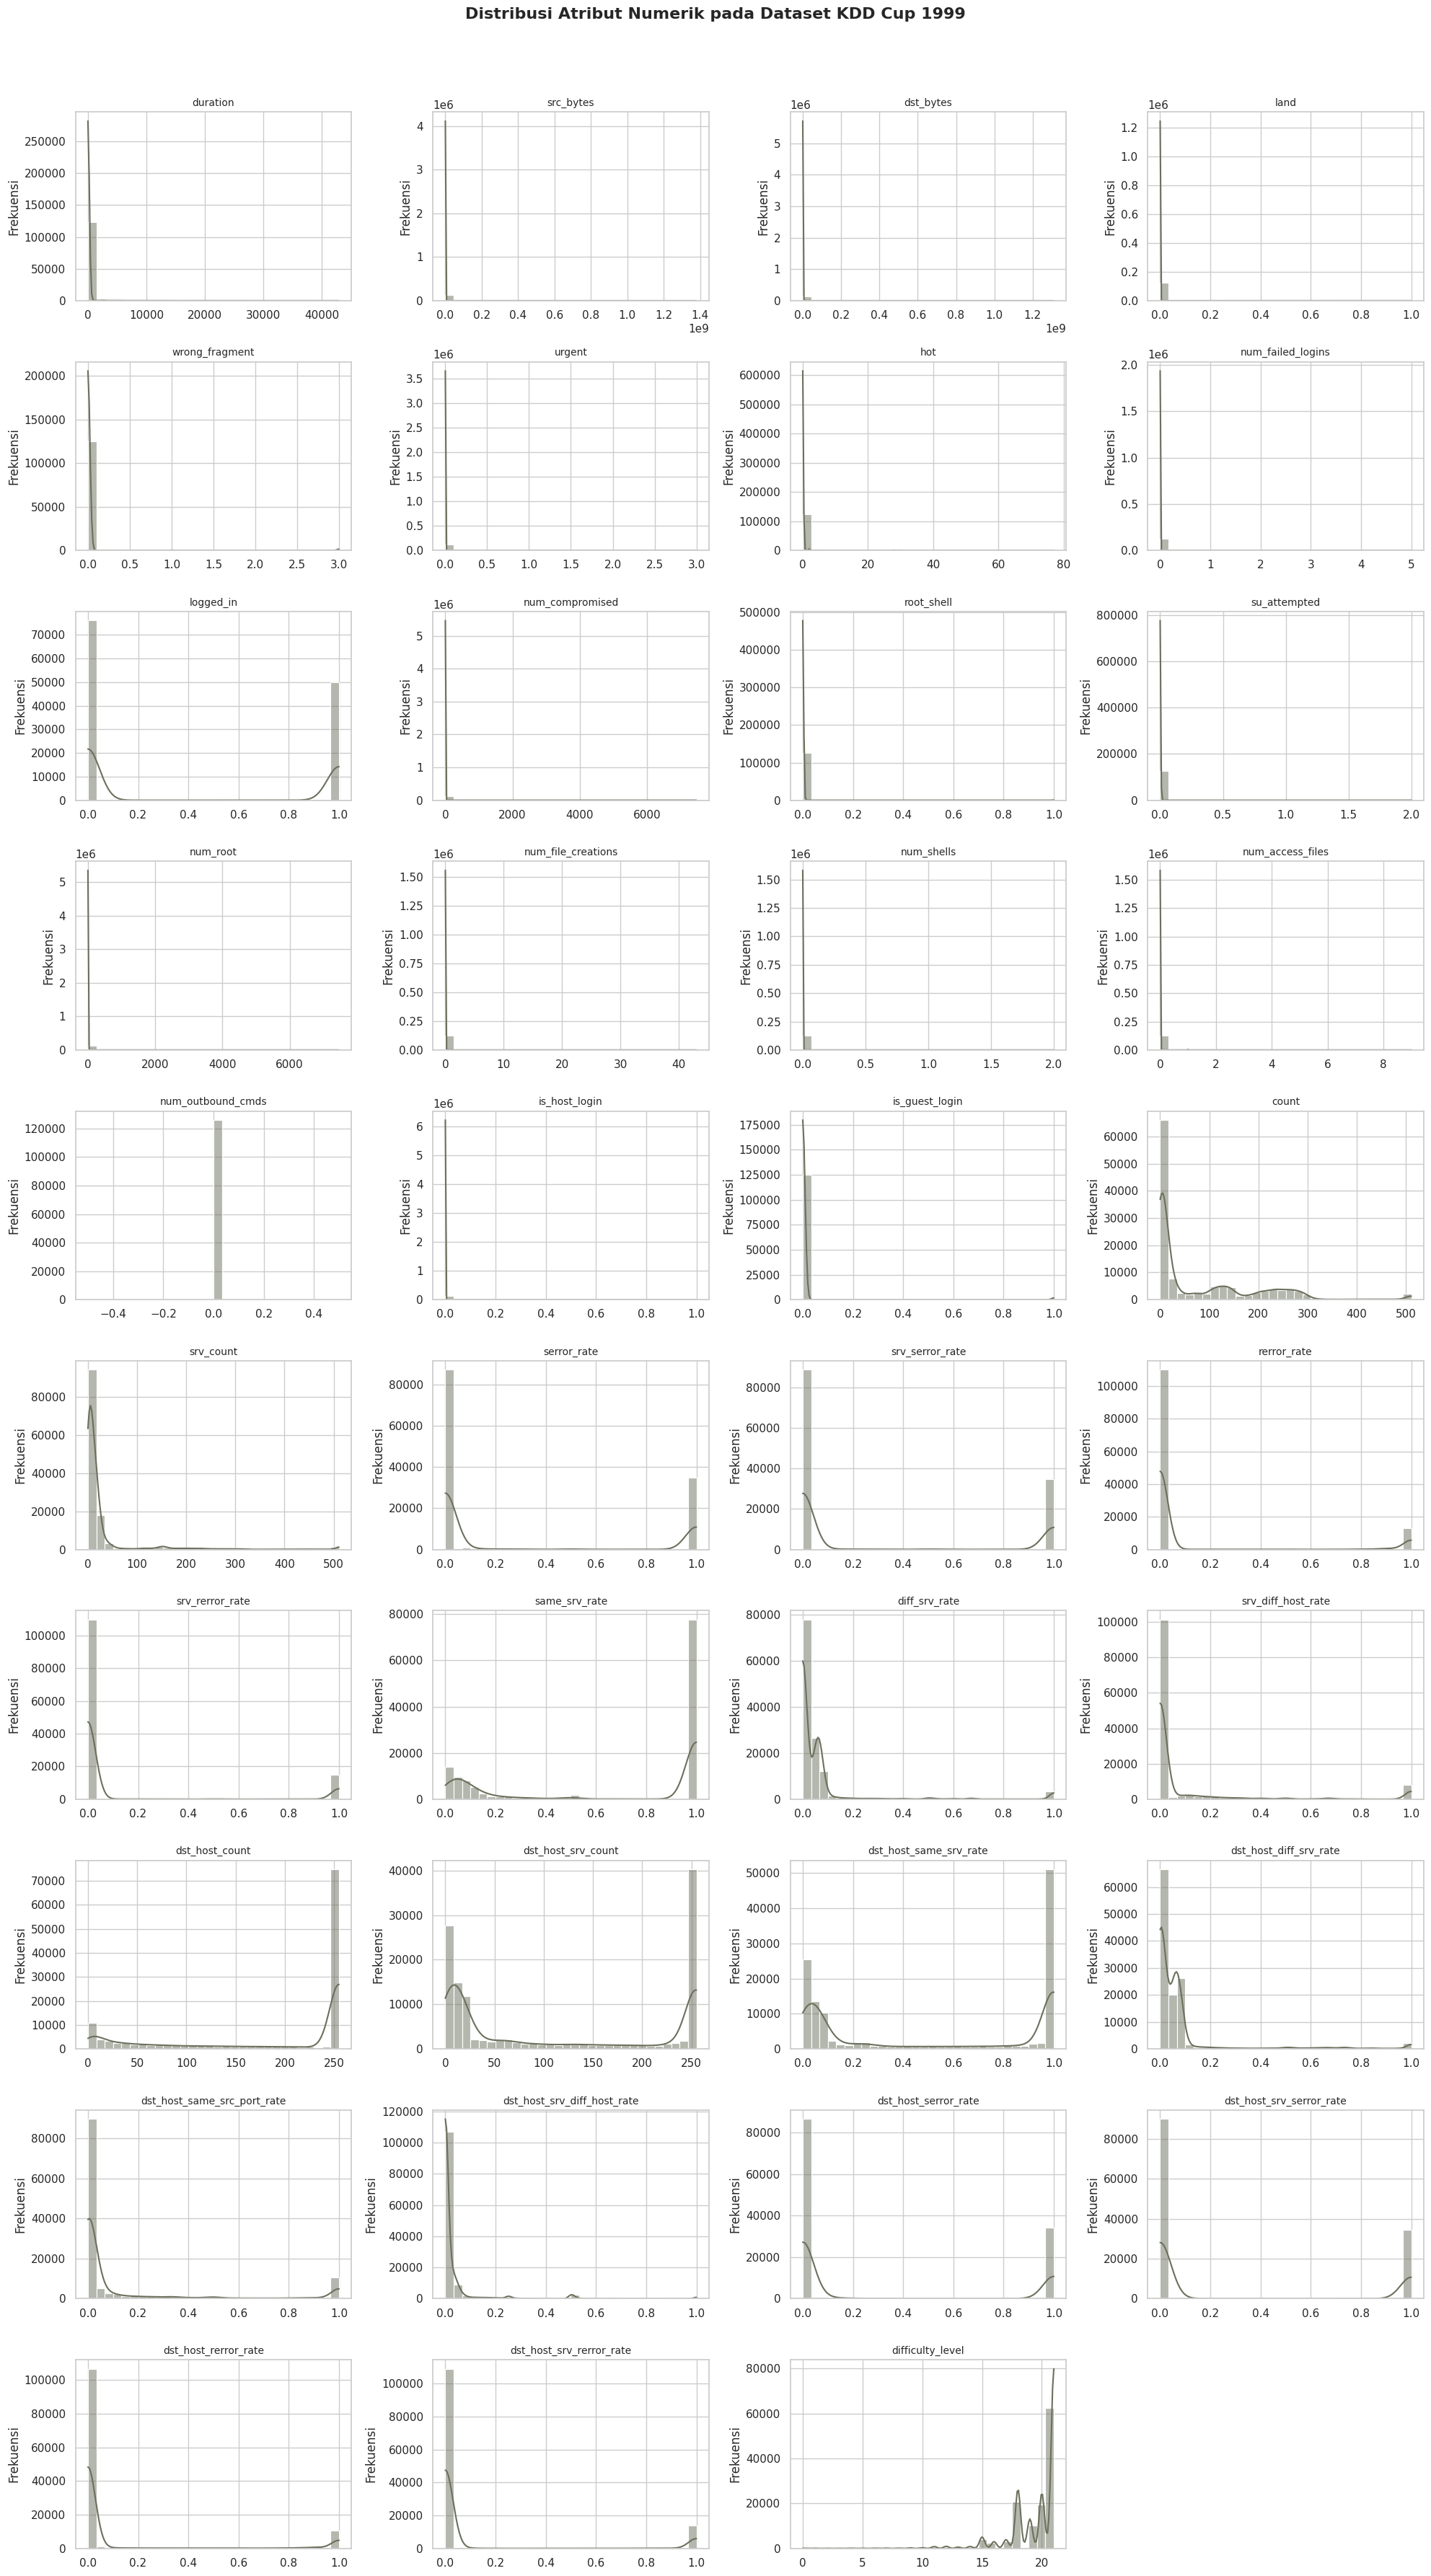

In [ ]:
# Analisis distribusi atribut numerik
sns.set(style="whitegrid")
num_features = len(num_cols)
cols_per_row = 4
rows = (num_features // cols_per_row) + int(num_features % cols_per_row > 0)

plt.figure(figsize=(20, rows * 3.5))
plt.suptitle("Distribusi Atribut Numerik pada Dataset KDD Cup 1999", fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df[col], bins=30, kde=True, color="#6B705C")
    plt.title(col, fontsize=10)
    plt.xlabel("")
    plt.ylabel("Frekuensi")
    plt.tight_layout()

plt.show()

In [ ]:
# Deteksi skewness
skewness = df[num_cols].skew().sort_values(ascending=False)
print("\nNilai Skewness (kemencengan):")
print(skewness)


Nilai Skewness (kemencengan):
is_host_login                  354.926753
dst_bytes                      290.052911
num_compromised                250.107883
num_root                       236.913724
src_bytes                      190.669347
urgent                         149.914509
land                            70.965063
num_shells                      59.592151
num_file_creations              55.665341
num_failed_logins               53.764424
num_access_files                45.554961
su_attempted                    42.435591
root_shell                      27.247411
hot                             12.589886
duration                        11.880230
wrong_fragment                  11.457988
is_guest_login                  10.155746
dst_host_srv_diff_host_rate      5.548174
srv_count                        4.694162
diff_srv_rate                    4.379815
dst_host_diff_srv_rate           3.609600
srv_diff_host_rate               2.860355
dst_host_rerror_rate             2.347446
dst

In [ ]:
# Normalisasi
scaler = MinMaxScaler()
df_normalized = df.copy()
df_normalized[num_cols] = scaler.fit_transform(df[num_cols])
print("\nData setelah normalisasi (5 baris pertama):")
print(df_normalized.head())


Data setelah normalisasi (5 baris pertama):
   duration protocol_type   service flag     src_bytes     dst_bytes  land  \
0       0.0           tcp  ftp_data   SF  3.558064e-07  0.000000e+00   0.0   
1       0.0           udp     other   SF  1.057999e-07  0.000000e+00   0.0   
2       0.0           tcp   private   S0  0.000000e+00  0.000000e+00   0.0   
3       0.0           tcp      http   SF  1.681203e-07  6.223962e-06   0.0   
4       0.0           tcp      http   SF  1.442067e-07  3.206260e-07   0.0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0             0.0     0.0  0.0  ...                    0.17   
1             0.0     0.0  0.0  ...                    0.00   
2             0.0     0.0  0.0  ...                    0.10   
3             0.0     0.0  0.0  ...                    1.00   
4             0.0     0.0  0.0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                        

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
# Ubah label jadi biner untuk visualisasi (normal=0, attack=1)
X = df_normalized[num_cols]
y = df_normalized['label']
y_binary = y.apply(lambda x: 0 if 'normal' in str(x).lower() else 1)

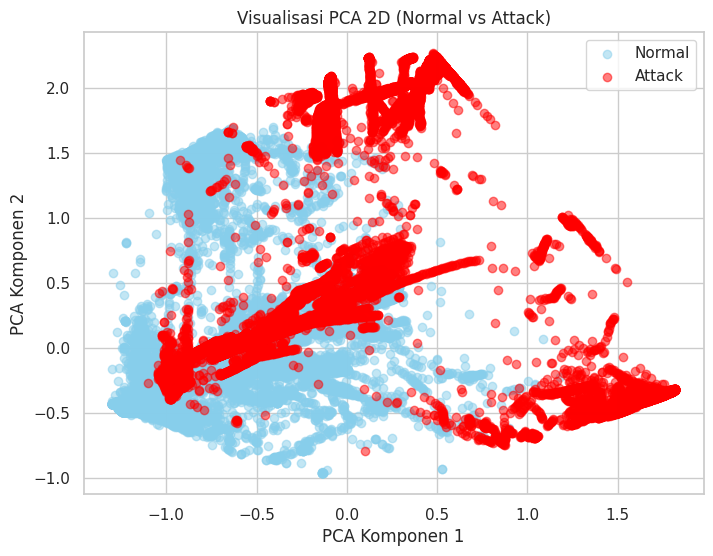

In [ ]:
# PCA 2D visualization
pca_2d = PCA(n_components=2)
pca_result_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(pca_result_2d[y_binary == 0, 0], pca_result_2d[y_binary == 0, 1],
            c='skyblue', label='Normal', alpha=0.5)
plt.scatter(pca_result_2d[y_binary == 1, 0], pca_result_2d[y_binary == 1, 1],
            c='red', label='Attack', alpha=0.5)
plt.title("Visualisasi PCA 2D (Normal vs Attack)")
plt.xlabel("PCA Komponen 1")
plt.ylabel("PCA Komponen 2")
plt.legend()
plt.show()

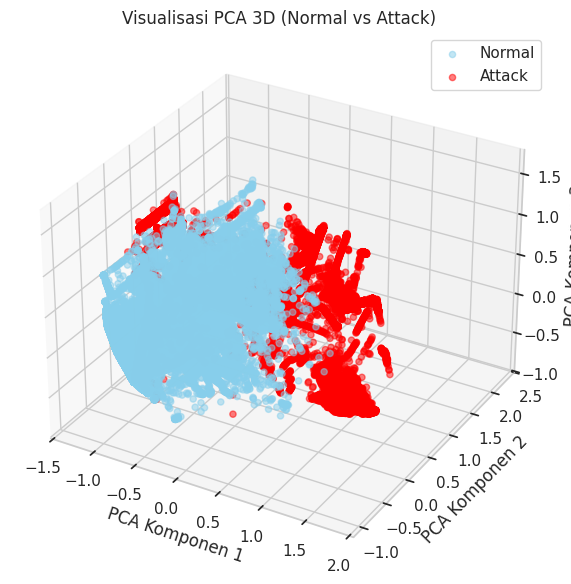

In [ ]:
# PCA 3D visualization
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pca_result_3d[y_binary == 0, 0], pca_result_3d[y_binary == 0, 1],
           pca_result_3d[y_binary == 0, 2], c='skyblue', label='Normal', alpha=0.5)
ax.scatter(pca_result_3d[y_binary == 1, 0], pca_result_3d[y_binary == 1, 1],
           pca_result_3d[y_binary == 1, 2], c='red', label='Attack', alpha=0.5)
ax.set_title("Visualisasi PCA 3D (Normal vs Attack)")
ax.set_xlabel("PCA Komponen 1")
ax.set_ylabel("PCA Komponen 2")
ax.set_zlabel("PCA Komponen 3")
ax.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


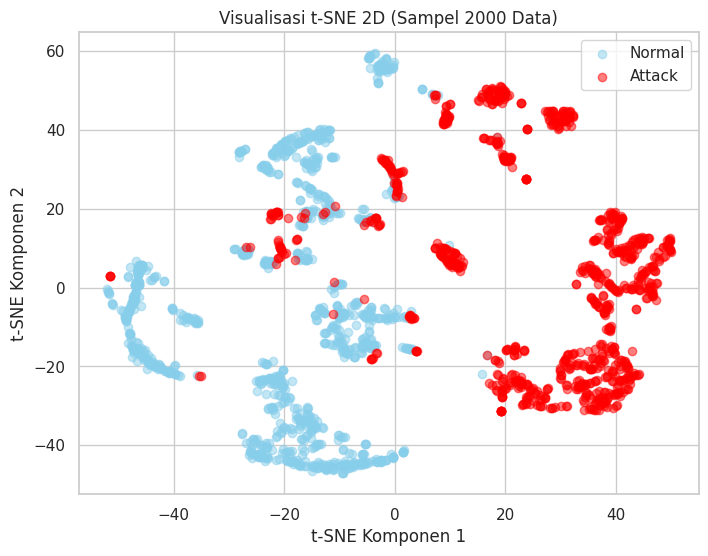

In [ ]:
# t-SNE visualization (lebih detail), biru = data normal, merah = anomali
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_sample = X.sample(2000, random_state=42)
y_sample = y_binary.loc[X_sample.index]

tsne_result = tsne.fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(tsne_result[y_sample == 0, 0], tsne_result[y_sample == 0, 1],
            c='skyblue', label='Normal', alpha=0.5)
plt.scatter(tsne_result[y_sample == 1, 0], tsne_result[y_sample == 1, 1],
            c='red', label='Attack', alpha=0.5)
plt.title("Visualisasi t-SNE 2D (Sampel 2000 Data)")
plt.xlabel("t-SNE Komponen 1")
plt.ylabel("t-SNE Komponen 2")
plt.legend()
plt.show()

**2. IMPLEMENTASI TIGA PENDEKATAN**

STATISTIK: UJI GRUBBS ATAU METODE LIKELIHOOD-BASED (MIXTURE MODEL M & A)

DISTANCE-BASED: GUNAKAN K-NN ATAU MAHALANOBIS DISTANCE

DENSITY-BASED: GUNAKAN LOF (LOCAL OUTLIER FACTOR)

In [ ]:
from scipy import stats
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from scipy.spatial.distance import mahalanobis
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


[Grubbs Test] Jumlah outlier pada 'src_bytes': 7


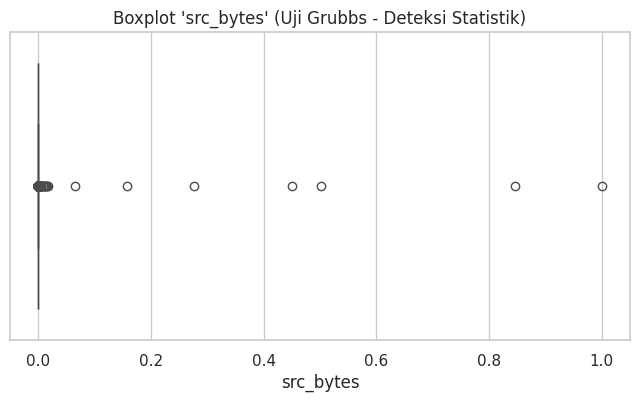

In [ ]:
# Deteksi outlier menggunakan Grubbs' Test untuk satu variabel, mengembalikan daftar index outlier
def grubbs_test(series, alpha=0.05):
    data = series.dropna()
    n = len(data)
    mean_y = np.mean(data)
    std_y = np.std(data)
    G = abs(data - mean_y) / std_y
    t_crit = stats.t.ppf(1 - alpha / (2 * n), n - 2)
    G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))

    outliers = data[G > G_crit]
    return outliers.index

# Contoh: deteksi anomali dengan Grubbs’ Test pada kolom `src_bytes`
outlier_idx = grubbs_test(df_normalized["src_bytes"])
print(f"\n[Grubbs Test] Jumlah outlier pada 'src_bytes': {len(outlier_idx)}")

plt.figure(figsize=(8,4))
sns.boxplot(x=df_normalized["src_bytes"])
plt.title("Boxplot 'src_bytes' (Uji Grubbs - Deteksi Statistik)")
plt.show()

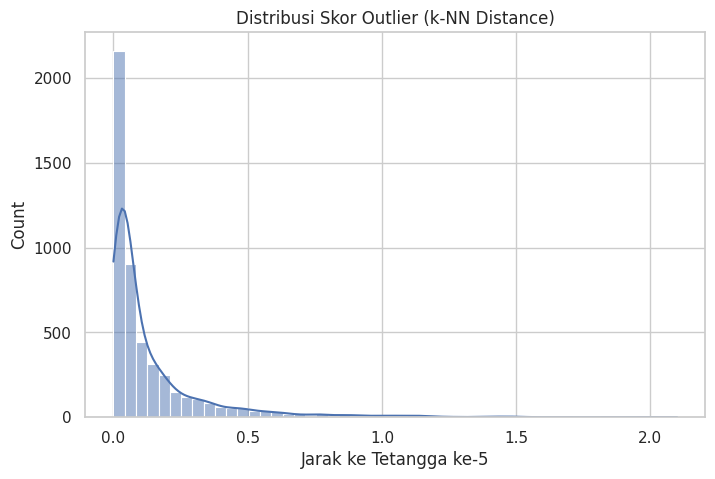

[k-NN Distance] Jumlah data terdeteksi sebagai outlier: 250


In [ ]:
# Pendekatan berbasis jarak: k-NN Distance
def knn_outlier_scores(X, k=5):
    nbrs = NearestNeighbors(n_neighbors=k)
    nbrs.fit(X)
    distances, _ = nbrs.kneighbors(X)
    # Gunakan jarak ke tetangga terjauh sebagai skor outlier
    scores = distances[:, -1]
    return scores

# Gunakan subset agar komputasi cepat
X_sample = df_normalized[num_cols].sample(5000, random_state=42)
scores_knn = knn_outlier_scores(X_sample, k=5)

plt.figure(figsize=(8,5))
sns.histplot(scores_knn, bins=50, kde=True)
plt.title("Distribusi Skor Outlier (k-NN Distance)")
plt.xlabel("Jarak ke Tetangga ke-5")
plt.show()

threshold_knn = np.percentile(scores_knn, 95)
outliers_knn = np.where(scores_knn > threshold_knn)[0]
print(f"[k-NN Distance] Jumlah data terdeteksi sebagai outlier: {len(outliers_knn)}")

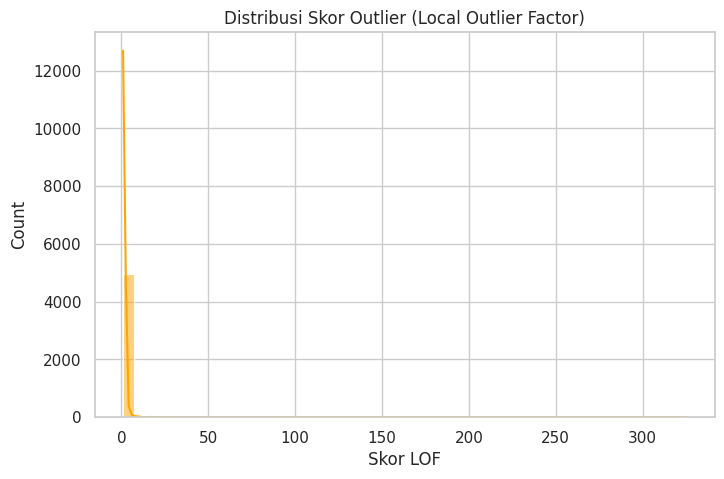

[LOF] Jumlah data terdeteksi sebagai outlier: 250


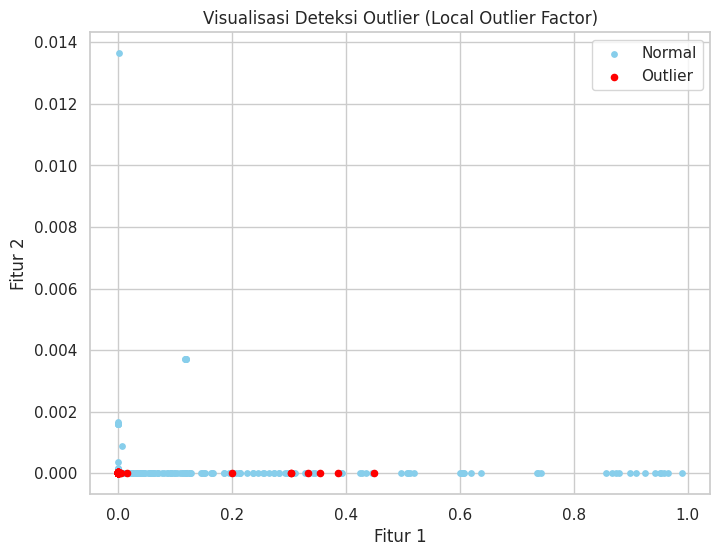

In [ ]:
# Pendekatan berbasis densitas
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(X_sample)
lof_scores = -lof.negative_outlier_factor_  # Skor besar = outlier kuat

plt.figure(figsize=(8,5))
sns.histplot(lof_scores, bins=50, kde=True, color='orange')
plt.title("Distribusi Skor Outlier (Local Outlier Factor)")
plt.xlabel("Skor LOF")
plt.show()

outliers_lof = np.where(y_pred_lof == -1)[0]
print(f"[LOF] Jumlah data terdeteksi sebagai outlier: {len(outliers_lof)}")

# Visualisasi hasil LOF
plt.figure(figsize=(8,6))
plt.scatter(X_sample.iloc[:,0], X_sample.iloc[:,1], c='skyblue', s=15, label='Normal')
plt.scatter(X_sample.iloc[outliers_lof,0], X_sample.iloc[outliers_lof,1],
            c='red', s=20, label='Outlier')
plt.title("Visualisasi Deteksi Outlier (Local Outlier Factor)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.show()

In [ ]:
# Hasil prediksi

# Grubbs Test (Statistical)
outlier_idx = grubbs_test(df_normalized["src_bytes"])
y_pred_grubbs = np.zeros(len(df_normalized))
y_pred_grubbs[outlier_idx] = 1  # 1 = outlier
print(f"[Grubbs Test] Jumlah data outlier: {y_pred_grubbs.sum()}")

# k-NN Distance (Distance-based)
y_pred_knn = np.zeros(len(X_sample))
y_pred_knn[outliers_knn] = 1
print(f"[k-NN Distance] Jumlah data outlier: {y_pred_knn.sum()}")

# LOF (Density-based)
y_pred_lof = (y_pred_lof == -1).astype(int)
print(f"[LOF] Jumlah data outlier: {y_pred_lof.sum()}")

[Grubbs Test] Jumlah data outlier: 7.0
[k-NN Distance] Jumlah data outlier: 250.0
[LOF] Jumlah data outlier: 250


**3. EVALUASI HASIL**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [ ]:
# Fungsi evaluasi hasil deteksi outlier berdasarkan metrik evaluasi utama: precision, recall, f1-score, AUC-ROS, false alarm ate (FAR), detection rate (DR)
def evaluate_outlier_detection(y_true, y_pred, method_name):
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    FAR = fp / (fp + tn)
    DR = tp / (tp + fn)

    return {
        "Metode": method_name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC": auc,
        "False Alarm Rate": FAR,
        "Detection Rate": DR
    }

In [ ]:
# Gunakan label asli dari data (0 = normal, 1 = attack)
y = df_normalized['label'].astype(str)
y_binary = y.apply(lambda x: 0 if 'normal' in x else 1)

# Evaluasi semua metode
results = []
results.append(evaluate_outlier_detection(y_binary.iloc[:len(y_pred_grubbs)], y_pred_grubbs, "Statistical (Grubbs)"))
results.append(evaluate_outlier_detection(y_binary.iloc[:len(y_pred_knn)], y_pred_knn, "Distance-based (kNN)"))
results.append(evaluate_outlier_detection(y_binary.iloc[:len(y_pred_lof)], y_pred_lof, "Density-based (LOF)"))

eval_df = pd.DataFrame(results)
print("\n Ringkasan Hasil Evaluasi:")
print(eval_df)



 Ringkasan Hasil Evaluasi:
                 Metode  Precision    Recall  F1-Score       AUC  \
0  Statistical (Grubbs)   0.857143  0.000102  0.000205  0.500044   
1  Distance-based (kNN)   0.448000  0.047619  0.086088  0.497752   
2   Density-based (LOF)   0.496000  0.052721  0.095311  0.502569   

   False Alarm Rate  Detection Rate  
0          0.000015        0.000102  
1          0.052115        0.047619  
2          0.047583        0.052721  


**4. ANALISIS KOMPARATIF**

Jumlah Outlier yang Terdeteksi Tiap Metode:
               Metode  Jumlah Outlier
0  Grubbs (Statistik)               7
1        k-NN (Jarak)             250
2      LOF (Densitas)             250


/tmp/ipython-input-3954212932.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='Metode', y='Jumlah Outlier', palette='Set2')


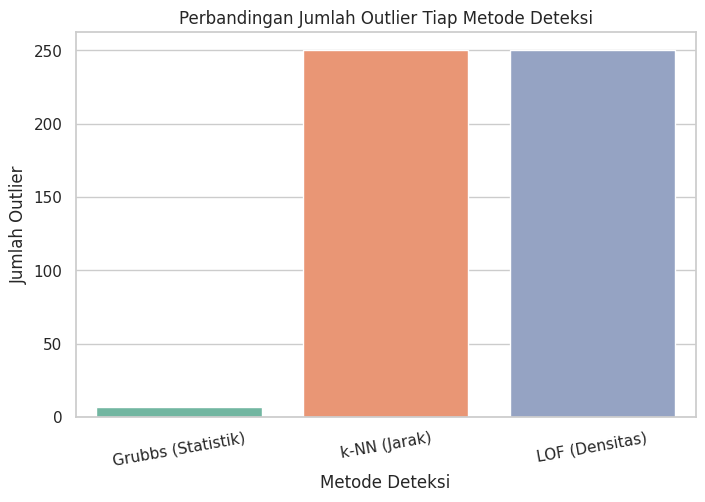

In [ ]:
# Buat DataFrame ringkasan hasil deteksi
comparison = pd.DataFrame({
    'Metode': ['Grubbs (Statistik)', 'k-NN (Jarak)', 'LOF (Densitas)'],
    'Jumlah Outlier': [
        len(y_pred_grubbs[y_pred_grubbs == 1]),
        len(y_pred_knn[y_pred_knn == 1]),
        len(y_pred_lof[y_pred_lof == 1])
    ]
})

print("Jumlah Outlier yang Terdeteksi Tiap Metode:")
print(comparison)

# Visualisasi perbandingan jumlah outlier
plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x='Metode', y='Jumlah Outlier', palette='Set2')
plt.title("Perbandingan Jumlah Outlier Tiap Metode Deteksi")
plt.ylabel("Jumlah Outlier")
plt.xlabel("Metode Deteksi")
plt.xticks(rotation=10)
plt.show()

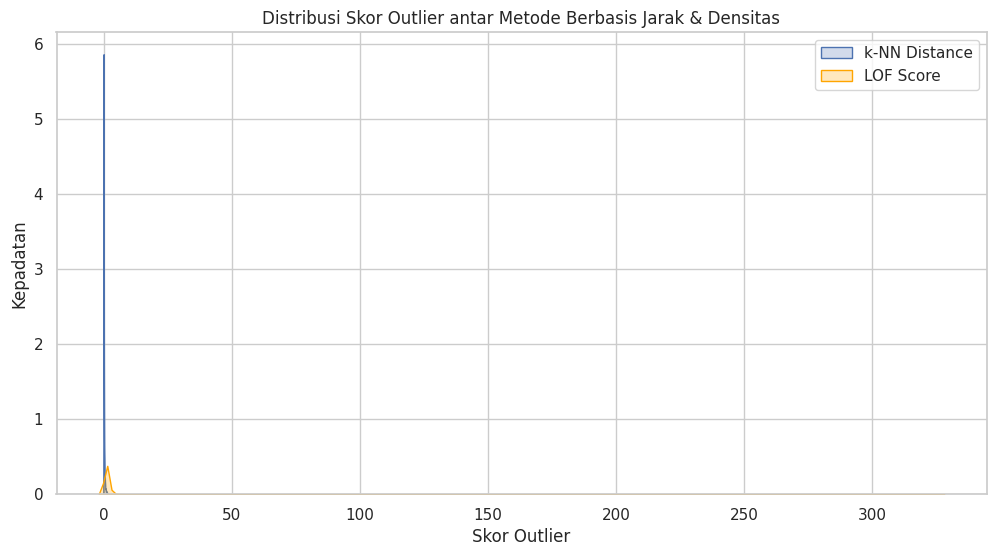

In [ ]:
# Distribusi skor deteksi dari tiap metode
plt.figure(figsize=(12,6))
sns.kdeplot(scores_knn, label='k-NN Distance', fill=True)
sns.kdeplot(lof_scores, label='LOF Score', fill=True, color='orange')
plt.title("Distribusi Skor Outlier antar Metode Berbasis Jarak & Densitas")
plt.xlabel("Skor Outlier")
plt.ylabel("Kepadatan")
plt.legend()
plt.show()